### PageRank

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
candidate_corr_thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]

In [3]:
train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)
train_corr = train_residuals.corr()

In [4]:
train_residuals.head()

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2016-07-06,-0.641362,-0.110390,-0.695032,-0.678762,0.029421,-0.210469,0.014899,-0.136803,-0.289925,-0.134165,...,-0.237076,-0.116626,0.216990,-0.232623,-0.404827,-0.004539,-0.160922,-0.518294,-0.298700,-0.469089
2016-07-07,-0.122738,-0.244931,0.178752,0.074969,0.077457,-0.168629,-0.322739,-0.383542,0.275375,0.095714,...,0.209268,-0.332896,1.162601,0.518853,-0.175565,-0.341038,0.120248,0.098960,-0.380224,0.076164
2016-07-08,-1.119867,-0.998485,-0.543556,-0.919744,-0.667190,-1.078692,-0.848781,-1.177636,-0.872179,-0.949916,...,-1.133458,-0.712719,-0.501263,-0.741137,-1.306642,-0.845859,-0.798725,-0.723843,-1.136524,-0.931803
2016-07-11,-0.086504,-0.250686,0.186754,0.128552,-0.159617,-0.192579,-0.215351,-0.466366,-0.116664,-0.105978,...,-0.264394,-0.461706,0.162203,-0.110785,-0.245704,-0.352981,-0.131869,-0.121882,-0.343827,0.022674
2016-07-12,-0.691024,-0.464972,-0.244379,-0.285271,-0.149046,-0.447581,-0.470633,-0.708057,-0.476309,-0.157242,...,-0.347170,-0.743883,1.092272,-1.037978,-0.499197,-0.638584,0.028809,-0.457133,-0.794754,-0.188437


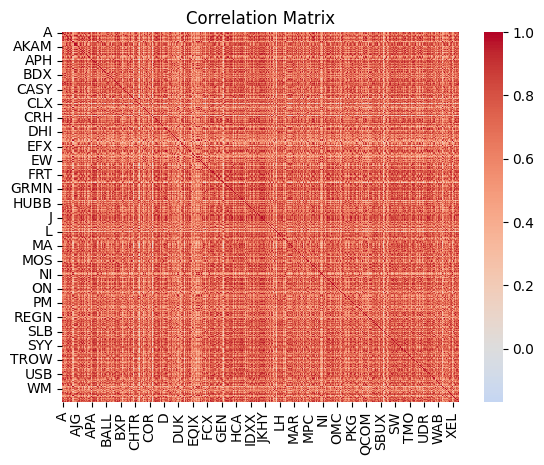

In [10]:

sns.heatmap(
    train_corr,
    cmap="coolwarm",
    center=0,
)

plt.title(f"Correlation Matrix")
plt.show()

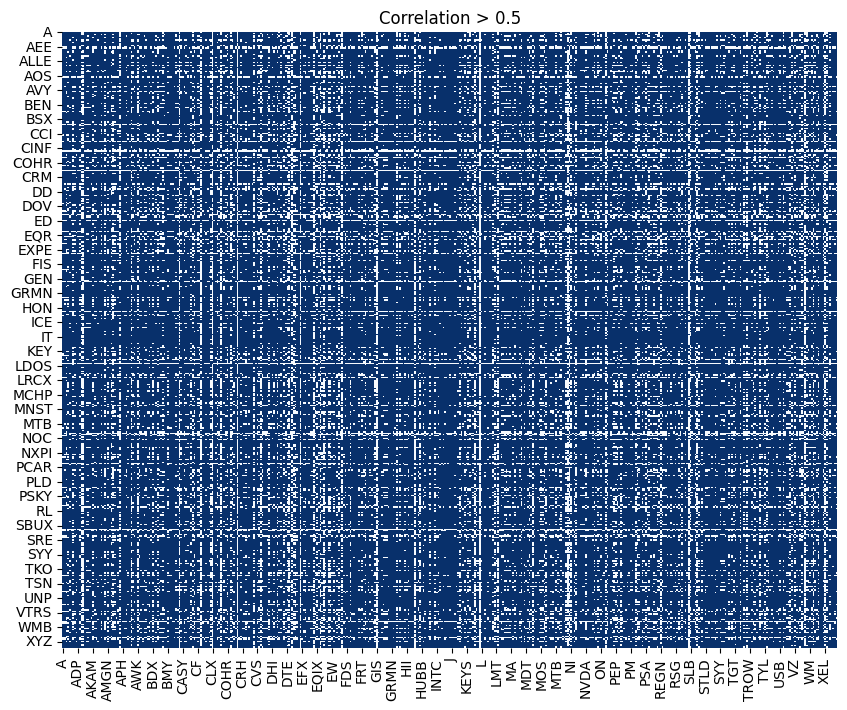

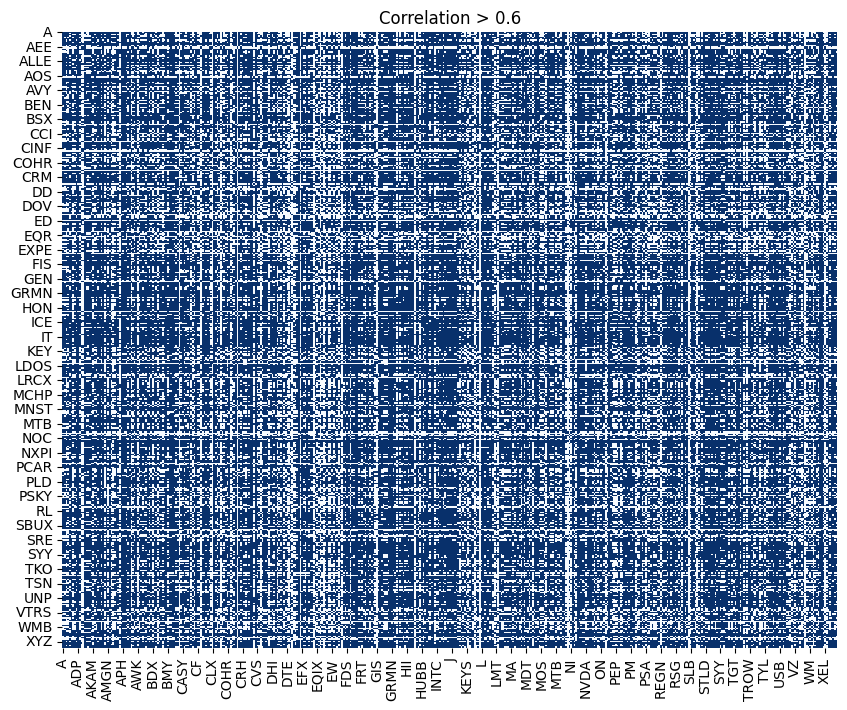

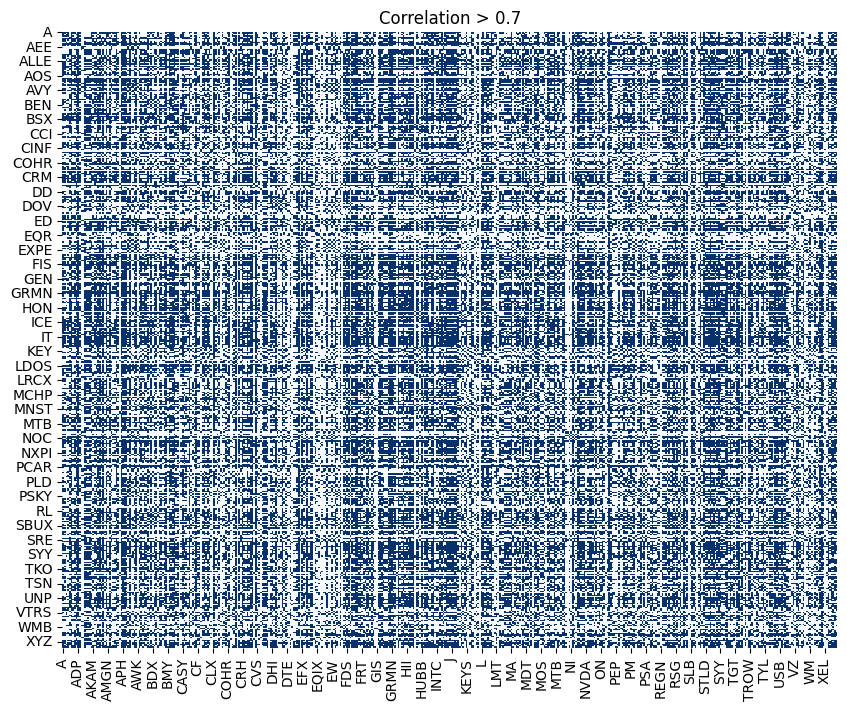

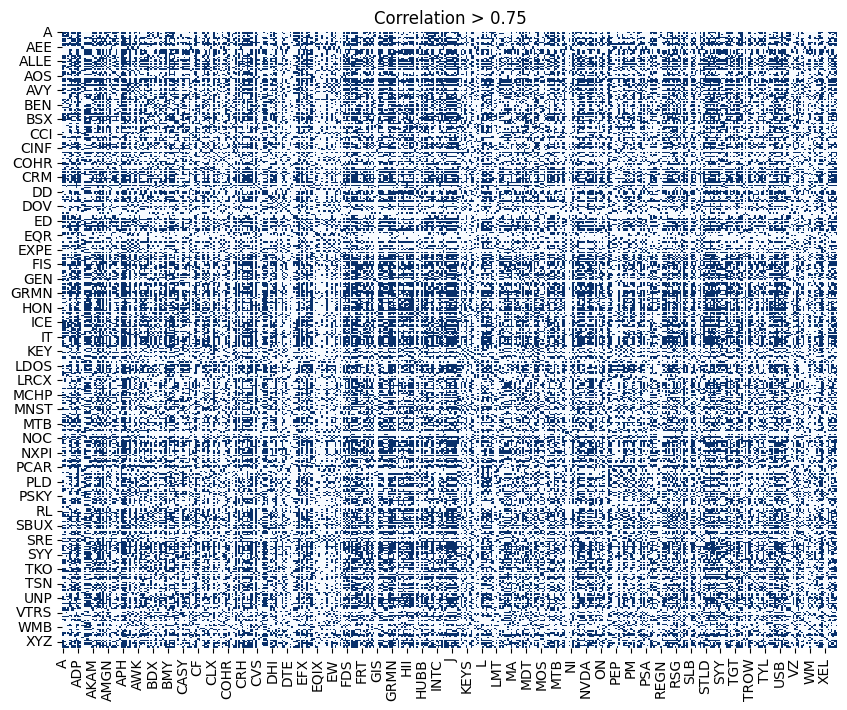

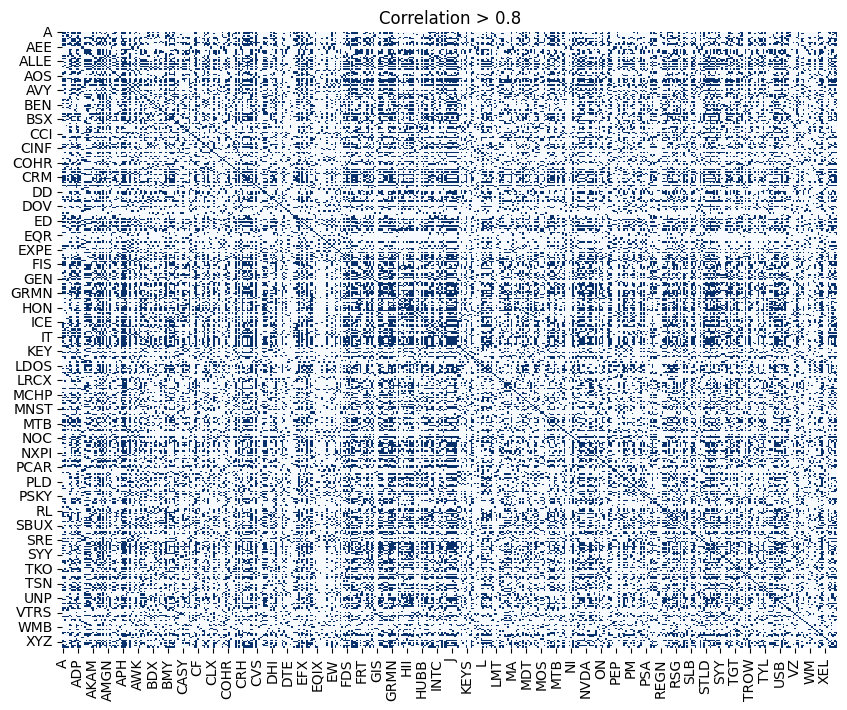

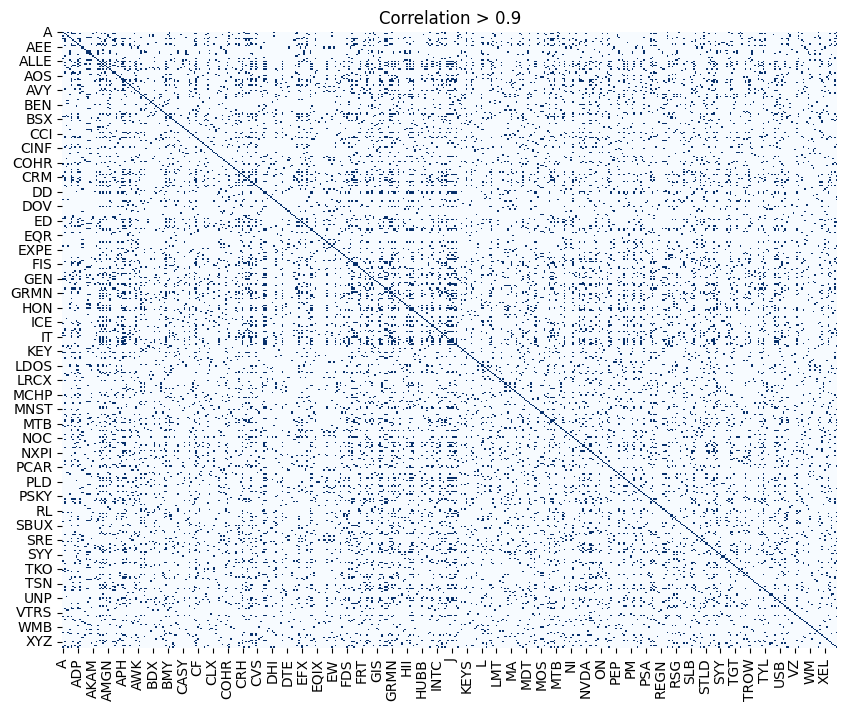

In [ ]:
for candidate_threshold in candidate_corr_thresholds:
    plt.figure(figsize=(10, 8))
    sns.heatmap(train_corr > candidate_threshold, cmap="Blues", cbar=False)
    plt.title(f"Correlation > {candidate_threshold}")
    plt.show()

Purely hueristically, I choose a threshold of 0.8, because this is the first value for which the diagonal line is distinct from the rest of the data on the heatmap. (WIP - will explain in more detail)

In [ ]:
# config
CORR_THRESHOLD = 0.8 
NUM_ASSETS = 25

In [68]:
def pagerank(mtx, beta=0.85, tol=1e-6, max_iter=100):
    """
    Compute PageRank scores.

    Parameters:
        mtx (pd.DataFrame or np.ndarray): adjacency matrix (0/1 or weights)
        beta (float): damping factor
        tol (float): convergence tolerance
        max_iter (int): max iterations

    Returns:
        np.ndarray: PageRank vector
    """
    # convert to numpy
    A = mtx.to_numpy() if hasattr(mtx, "to_numpy") else mtx
    n = A.shape[0]

    # row-normalize (handle dangling nodes)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    P = A / row_sums

    # initialize rank vector
    r = np.ones(n) / n

    # power iteration
    for _ in range(max_iter):
        r_new = beta * P.T @ r + (1 - beta) / n

        if np.linalg.norm(r_new - r, 1) < tol:
            break

        r = r_new

    return r

In [69]:
# construct weighted link matrix
weight_matrix = train_corr.copy()
weight_matrix[train_corr <= CORR_THRESHOLD] = 0
weight_matrix = weight_matrix ** 2  # emphasize stronger correlations
weight_matrix = weight_matrix.mask(np.eye(len(weight_matrix), dtype=bool), 0)

# run pagerank on weighted matrix
r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(NUM_ASSETS)
print(top_assets)

    Asset  PageRank
80    CDW  0.004191
116  CTSH  0.004134
24   AMCR  0.004057
202   HAS  0.003974
307   NKE  0.003873
36    APH  0.003856
390   STZ  0.003834
147    EL  0.003834
457    WY  0.003828
258   LIN  0.003823
198  GRMN  0.003803
37    APO  0.003799
62    BLK  0.003788
211   HPQ  0.003785
142   ECL  0.003752
329  PAYX  0.003706
108   CRH  0.003695
40   ARES  0.003692
246   KKR  0.003680
76   CBRE  0.003680
113   CSX  0.003657
5     ACN  0.003623
296   MSI  0.003587
231    IT  0.003585
402   TEL  0.003569


In [70]:
r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(NUM_ASSETS)
print(top_assets)

    Asset  PageRank
80    CDW  0.004191
116  CTSH  0.004134
24   AMCR  0.004057
202   HAS  0.003974
307   NKE  0.003873
36    APH  0.003856
390   STZ  0.003834
147    EL  0.003834
457    WY  0.003828
258   LIN  0.003823
198  GRMN  0.003803
37    APO  0.003799
62    BLK  0.003788
211   HPQ  0.003785
142   ECL  0.003752
329  PAYX  0.003706
108   CRH  0.003695
40   ARES  0.003692
246   KKR  0.003680
76   CBRE  0.003680
113   CSX  0.003657
5     ACN  0.003623
296   MSI  0.003587
231    IT  0.003585
402   TEL  0.003569


/tmp/ipykernel_20637/3860322374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis")


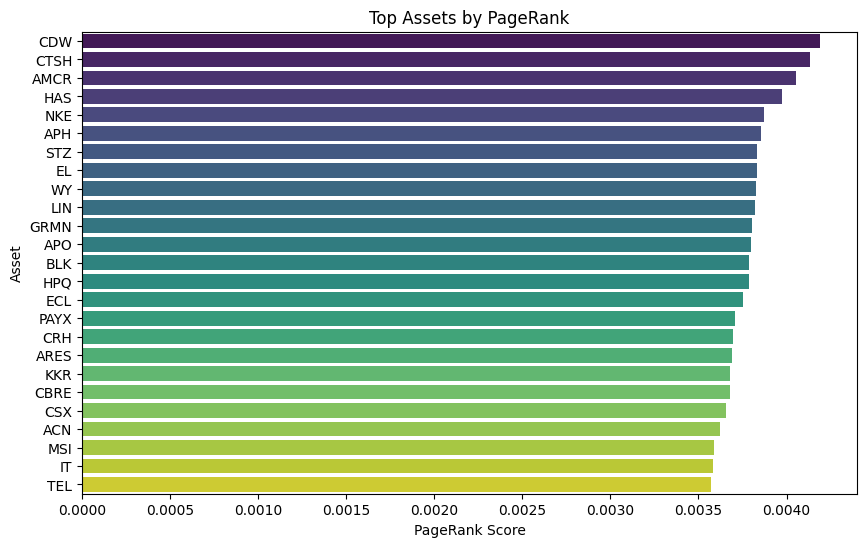

In [71]:
# make sorted bar graph of pagerank of top assets
plt.figure(figsize=(10, 6))
sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis")
plt.title("Top Assets by PageRank")
plt.xlabel("PageRank Score")
plt.ylabel("Asset")
plt.show()

In [72]:
full_residuals = pd.read_csv("../data/manipulated/residuals_full.csv", parse_dates=[0], index_col=0)

filtered_residuals = full_residuals[top_assets["Asset"]]

filtered_residuals.to_csv("../data/manipulated/pr_filtered_residuals.csv", index=True)

In [73]:
filtered_residuals.head()

,CDW,CTSH,AMCR,HAS,NKE,APH,STZ,EL,WY,LIN,...,PAYX,CRH,ARES,KKR,CBRE,CSX,ACN,MSI,IT,TEL
Date,,,,,,,,,,,,,,,,,,,,,
2016-07-06,-0.187709,-0.214904,-0.225427,-0.209318,-0.231739,-0.278004,-0.223617,-0.165157,-0.235572,-0.334489,...,-0.194025,-0.243942,-0.134326,-0.223822,-0.292393,-0.333242,-0.211960,-0.186913,-0.142516,-0.331314
2016-07-07,-0.220160,-0.089129,0.109670,-0.180916,-0.276886,-0.245809,0.298325,-0.193823,0.209147,-0.091320,...,0.060193,-0.220381,-0.151370,-0.359753,-0.120774,-0.050287,-0.168852,0.027042,-0.162174,-0.312032
2016-07-08,-1.042641,-0.951738,-0.870720,-0.834795,-1.022024,-1.319266,-0.699465,-0.918287,-1.133100,-1.075277,...,-1.046741,-1.078216,-0.927403,-1.123498,-1.048329,-1.128627,-1.078895,-0.863314,-0.861893,-1.324993
2016-07-11,-0.306091,-0.233511,-0.177947,-0.271133,-0.273637,-0.386947,-0.101586,-0.286614,-0.264677,-0.194988,...,-0.145629,-0.316278,-0.271500,-0.363762,-0.337476,-0.193298,-0.192129,-0.105827,-0.220202,-0.450798
2016-07-12,-0.548271,-0.412293,-0.184523,-0.341055,-0.351087,-0.631286,-0.039492,-0.350733,-0.346473,-0.419765,...,-0.239835,-0.590227,-0.671983,-0.931886,-0.650797,-0.522627,-0.448104,-0.214491,-0.396967,-0.735767
